In [94]:
import scanpy as sc
import squidpy as sq
import NaiveDE
import SpatialDE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

In [7]:
adata = sc.read("../../example/spatialDE/visium_hne.h5ad")

/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [190]:
coord=pd.read_csv("../important_processed_data/4.6_bayes_subset_coord.csv",index_col=0)

In [193]:
coord=coord.iloc[:,2:8]

In [197]:
coord=coord.drop_duplicates()

In [198]:
coord.index=coord["spot"]

In [211]:
coord.loc[stGingival.obs_names]["idents"]

subspot_76.5           sulcular_epi
subspot_176.4                   EBL
subspot_52.2              cornified
subspot_139.6    gingiva progenitor
subspot_60.6                    IBL
                        ...        
subspot_182.5       stratum corneum
subspot_60.5                    IBL
subspot_394.6      spinous+granular
subspot_374.1       stratum corneum
subspot_406.5       stratum corneum
Name: idents, Length: 1447, dtype: object

In [217]:
coord.iloc[:,[2,3]]

,imagerow,imagecol
spot,,
subspot_76.5,2205.972995,1175.147325
subspot_176.4,2205.972995,1492.366627
subspot_52.2,1426.923423,1333.756976
subspot_139.6,1560.274250,1321.556234
subspot_60.6,2381.434610,1211.749552
...,...,...
subspot_182.5,1553.255786,1138.545098
subspot_60.5,2353.360752,1211.749552
subspot_394.6,1981.382127,1028.738417


In [209]:
stGingival=stGingival[coord.index]

In [184]:
stGingival.obs_names

Index(['subspot_1.1', 'subspot_2.1', 'subspot_5.1', 'subspot_6.1',
       'subspot_7.1', 'subspot_8.1', 'subspot_12.1', 'subspot_13.1',
       'subspot_14.1', 'subspot_16.1',
       ...
       'subspot_403.6', 'subspot_405.6', 'subspot_406.6', 'subspot_408.6',
       'subspot_409.6', 'subspot_410.6', 'subspot_412.6', 'subspot_413.6',
       'subspot_414.6', 'subspot_415.6'],
      dtype='object', length=1448)

In [212]:
stGingival.obs["ident"]=coord.loc[stGingival.obs_names]["idents"]

/tmp/ipykernel_1544215/3808206262.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  stGingival.obs["ident"]=coord.loc[stGingival.obs_names]["idents"]


In [225]:
stGingival.obsm["spatial"]=np.array(coord.iloc[:,[3,2]])

In [19]:
adata.uns["spatial"]

{'V1_Adult_Mouse_Brain': {'images': {'hires': array([[[0.50980395, 0.52156866, 0.49411765],
           [0.50980395, 0.5176471 , 0.49411765],
           [0.50980395, 0.5176471 , 0.5019608 ],
           ...,
           [0.5019608 , 0.5137255 , 0.49019608],
           [0.5019608 , 0.5137255 , 0.49803922],
           [0.5019608 , 0.50980395, 0.49411765]],
   
          [[0.50980395, 0.5176471 , 0.49803922],
           [0.5137255 , 0.52156866, 0.49411765],
           [0.50980395, 0.5176471 , 0.49803922],
           ...,
           [0.49803922, 0.5137255 , 0.4862745 ],
           [0.49803922, 0.50980395, 0.49411765],
           [0.5019608 , 0.5137255 , 0.5019608 ]],
   
          [[0.5058824 , 0.5176471 , 0.49019608],
           [0.5137255 , 0.52156866, 0.5019608 ],
           [0.5058824 , 0.52156866, 0.5019608 ],
           ...,
           [0.5019608 , 0.5137255 , 0.49803922],
           [0.5019608 , 0.50980395, 0.49411765],
           [0.5058824 , 0.5137255 , 0.49803922]],
   
          ..

In [12]:
adata.obs["array_row"]

AAACAAGTATCTCCCA-1    50
AAACAATCTACTAGCA-1     3
AAACACCAATAACTGC-1    59
AAACAGAGCGACTCCT-1    14
AAACCGGGTAGGTACC-1    42
                      ..
TTGTTGTGTGTCAAGA-1    31
TTGTTTCACATCCAGG-1    58
TTGTTTCATTAGTCTA-1    60
TTGTTTCCATACAACT-1    45
TTGTTTGTGTAAATTC-1     7
Name: array_row, Length: 2688, dtype: int64

In [5]:
adata=sc.read_h5ad("../3.16_cytoscpace/processed_data/spatial_GSE2.h5ad")

/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [48]:
adata.obsm["spatial"].shape

(2688, 2)

/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/IPython/core/events.py:93: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


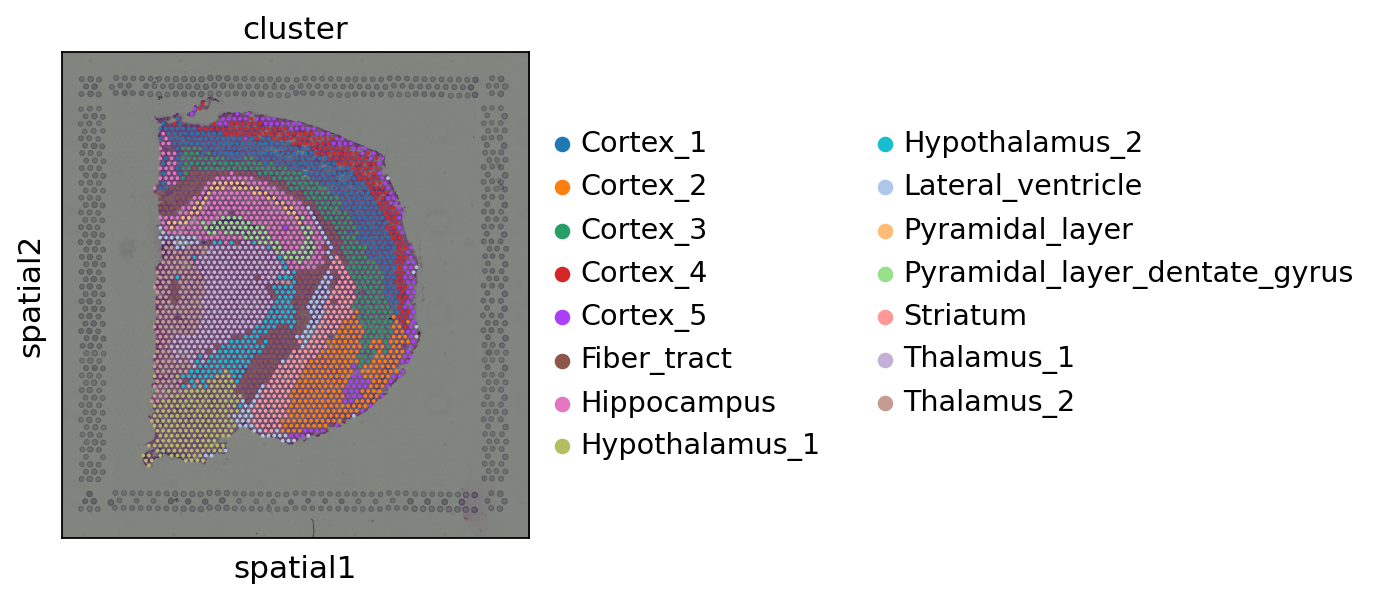

In [11]:
sq.pl.spatial_scatter(adata, color="cluster")

In [180]:
adata.X[1:10,1:10].toarray()

array([[0.        , 1.0922161 , 1.0922161 , 1.0922161 , 0.        ,
        1.6017576 , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.9803591 , 0.        ,
        0.6057939 , 0.        , 0.        , 0.9803591 ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        2.4223483 , 0.        , 0.        , 0.9977047 ],
       [0.        , 0.99697125, 0.        , 0.6179012 , 0.        ,
        0.        , 0.        , 0.        , 1.4861674 ],
       [0.        , 1.0170915 , 0.632638  , 0.632638  , 0.        ,
        1.510784  , 0.        , 0.        , 0.632638  ],
       [0.37266755, 0.8564579 , 0.8564579 , 1.3109268 , 0.8564579 ,
        1.1811161 , 0.6435385 , 0.        , 1.3109268 ],
       [0.        , 0.5269402 , 0.        , 0.87024   , 0.5269402 ,
        1.6414115 , 0.        , 0.        , 1.6414115 ],
       [0.5774457 , 1.4172912 , 0.        , 0.5774457 , 1.2073011 ,
        0.        , 0.        , 0.        , 1.2073011 ],


In [177]:
adata.obsm["spatial"]

array([[8230, 7237],
       [4170, 1611],
       [2519, 8315],
       ...,
       [3276, 8435],
       [3069, 6639],
       [4720, 2090]])

In [23]:
stBayes=pd.read_table("../3.16_cytoscpace/input/stMat_bayes.txt",index_col=0)

In [29]:
stCoord=pd.read_table("../3.16_cytoscpace/input/stCoord_bayes.txt",index_col=0)

In [31]:
stCoord["row"]

SpotID
subspot_1.1      35.333333
subspot_2.1      24.333333
subspot_5.1      28.333333
subspot_6.1      29.333333
subspot_7.1      23.333333
                   ...    
subspot_410.6    30.000000
subspot_412.6    22.000000
subspot_413.6    22.000000
subspot_414.6    24.000000
subspot_415.6    31.000000
Name: row, Length: 1448, dtype: float64

In [27]:
stGingival=sc.AnnData(stBayes.T)

In [227]:
stGingival.obsm["spatial"]=np.array(stCoord.loc[stGingival.obs_names])
stGingival.uns["spatial"]=adata.uns["spatial"]

In [222]:
stCoord.loc[stGingival.obs_names]

,row,col
subspot_76.5,25.000000,37.666667
subspot_176.4,33.666667,37.666667
subspot_52.2,29.333333,74.666667
subspot_139.6,29.000000,68.333333
subspot_60.6,26.000000,29.333333
...,...,...
subspot_182.5,24.000000,68.666667
subspot_60.5,26.000000,30.666667
subspot_394.6,21.000000,48.333333
subspot_374.1,28.333333,76.333333


In [50]:
stGingival.obs["in_tissue"]=1
stGingival.obs["array_row"]=stCoord["row"]
stGingival.obs["array_col"]=stCoord["col"]

In [87]:
stGingival.uns['spatial']["V1_Adult_Mouse_Brain"]["images"]["hires"].shape

(2000, 1921, 3)

In [162]:
stGingival.uns['spatial']["V1_Adult_Mouse_Brain"]["scalefactors"]["tissue_hires_scalef"]=35

In [163]:
np.array(stCoord)-40

array([[ -4.66666667,  39.33333333],
       [-15.66666667,  22.33333333],
       [-11.66666667,   2.33333333],
       ...,
       [-18.        ,   1.33333333],
       [-16.        ,  23.33333333],
       [ -9.        ,  36.33333333]])

In [168]:
stGingival.obsm["spatial"]=np.array(stCoord)-15

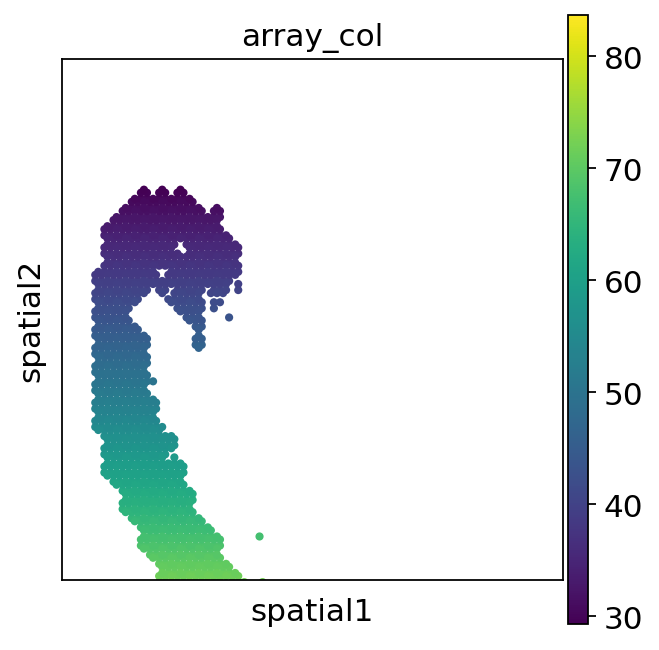

In [169]:
sq.pl.spatial_scatter(stGingival,img_alpha=0,color="array_col",size=0.01)

/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


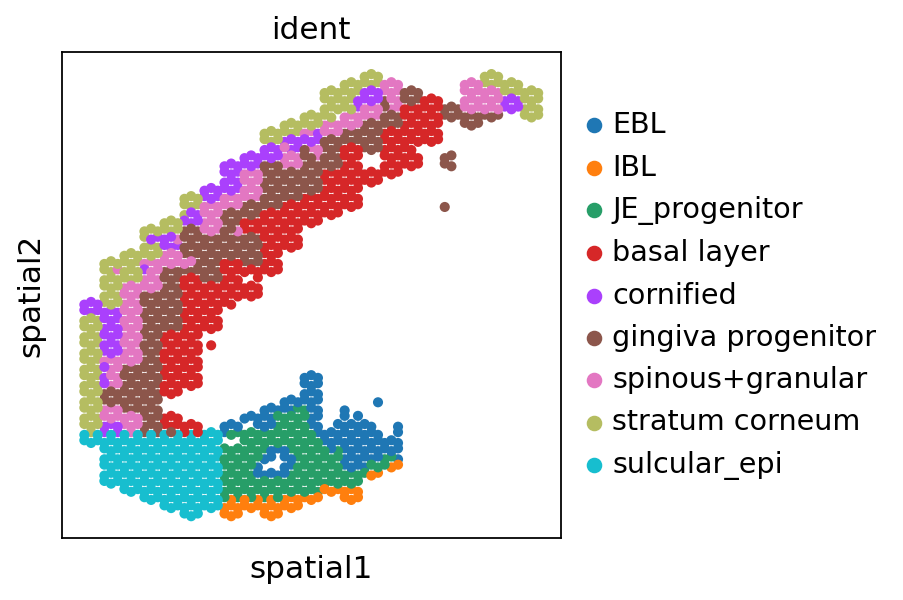

In [228]:
sc.pl.embedding(stGingival,basis="spatial",color="ident")

In [229]:
## preprocess datasets

In [231]:
sc.pp.normalize_total(stGingival, inplace=True)
sc.pp.log1p(stGingival)
sc.pp.highly_variable_genes(stGingival, flavor="seurat", n_top_genes=2000)

normalizing counts per cell
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:215: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


In [232]:
sc.pp.pca(stGingival)
sc.pp.neighbors(stGingival)
sc.tl.umap(stGingival)

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50


/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/si

    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:29)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:05)


Creating graph using `grid` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:00)
Calculating neighborhood enrichment using `1` core(s)


  0%|          | 0/1000 [00:00<?, ?/s]

Adding `adata.uns['ident_nhood_enrichment']`
Finish (0:00:01)


/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/squidpy/pl/_utils.py:557: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row_labels = adata.obs[key][row_order]


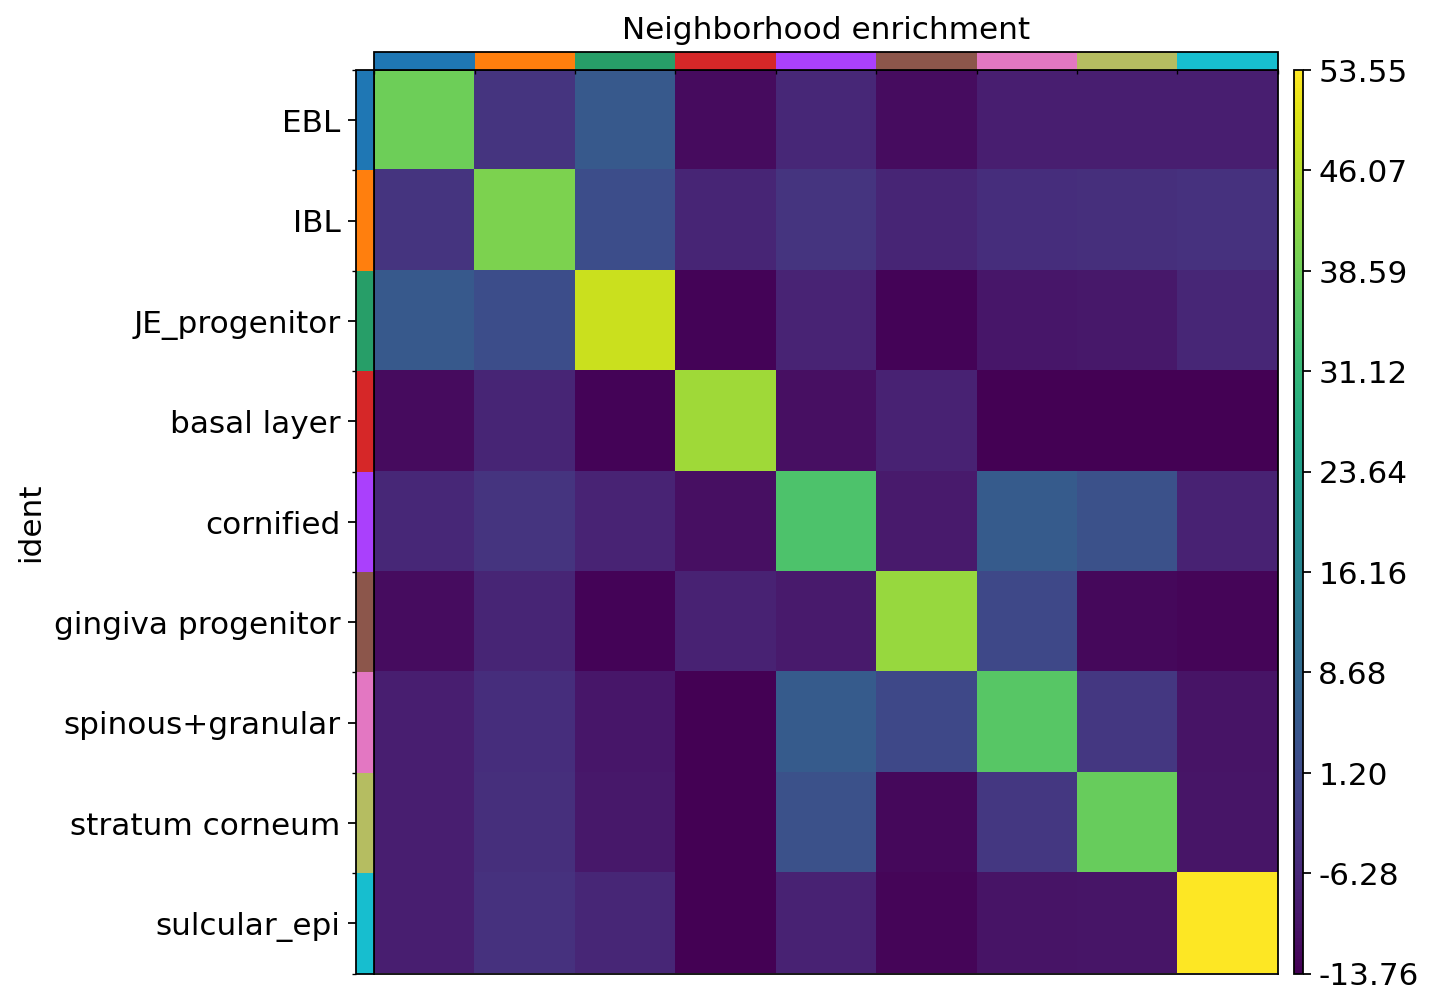

In [233]:
sq.gr.spatial_neighbors(stGingival)
sq.gr.nhood_enrichment(stGingival, cluster_key="ident")
sq.pl.nhood_enrichment(stGingival, cluster_key="ident")

In [235]:
sq.gr.spatial_autocorr(
    stGingival,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)

Calculating moran's statistic for `100` permutations using `1` core(s)


  0%|          | 0/100 [00:00<?, ?/s]

Adding `adata.uns['moranI']`
Finish (0:00:07)


In [237]:
stGingival.uns["moranI"].head(10)

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
Dusp10,0.903833,0.0,0.000313,0.0,0.009901,0.000581,0.0,0.0,0.009901
Bcat1,0.903661,0.0,0.000313,0.0,0.009901,0.000548,0.0,0.0,0.009901
Rnf224,0.901051,0.0,0.000313,0.0,0.009901,0.000562,0.0,0.0,0.009901
Slc28a3,0.900462,0.0,0.000313,0.0,0.009901,0.000565,0.0,0.0,0.009901
Apol8,0.899564,0.0,0.000313,0.0,0.009901,0.000537,0.0,0.0,0.009901
Muc1,0.898982,0.0,0.000313,0.0,0.009901,0.000587,0.0,0.0,0.009901
Il19,0.898971,0.0,0.000313,0.0,0.009901,0.000556,0.0,0.0,0.009901
Ly6k,0.898723,0.0,0.000313,0.0,0.009901,0.000552,0.0,0.0,0.009901
Spink5,0.896717,0.0,0.000313,0.0,0.009901,0.000721,0.0,0.0,0.009901
Hs3st1,0.896631,0.0,0.000313,0.0,0.009901,0.000540,0.0,0.0,0.009901


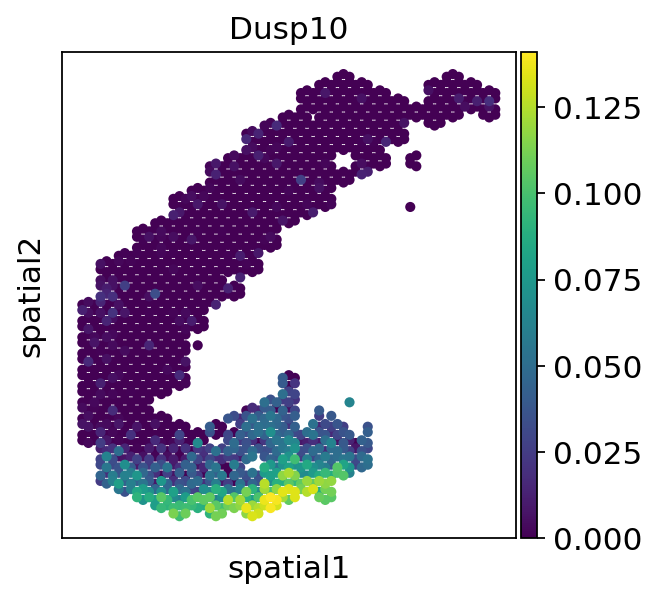

In [238]:
sc.pl.embedding(stGingival,basis="spatial",color="Dusp10")

## apply spatialDE

In [240]:
stGingival.var_names

Index(['Samd11', 'Noc2l', 'Klhl17', 'Plekhn1', 'Perm1', 'Isg15', 'Agrn',
       'Rnf223', '9430015G10Rik', 'Ttll10',
       ...
       'F8a', 'Fundc2', 'Cmc4', 'Mtcp1', 'Brcc3', 'Vbp1', 'Tmlhe', 'Spry3',
       'Vamp7', 'Il9r'],
      dtype='object', name='GENES', length=13728)

In [239]:
counts = sc.get.obs_df(stGingival, keys=list(stGingival.var_names), use_raw=False)

AttributeError: 'NoneType' object has no attribute 'var'

In [250]:
counts=stBayes.loc[:,stGingival.obs_names]

In [351]:
stGingival_raw=sc.AnnData(counts.T)

In [352]:
sc.pp.calculate_qc_metrics(stGingival_raw, inplace=True)

In [353]:
stGingival_raw

AnnData object with n_obs × n_vars = 1447 × 13728
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [354]:
total_counts = sc.get.obs_df(stGingival_raw, keys=["total_counts"])

In [355]:
counts=counts.T

In [356]:
norm_expr = NaiveDE.stabilize(counts.T).T

In [363]:
resid_expr = NaiveDE.regress_out(total_counts, norm_expr.T, "np.log(total_counts)").T

In [364]:
resid_expr

GENES,Samd11,Noc2l,Klhl17,Plekhn1,Perm1,Isg15,Agrn,Rnf223,9430015G10Rik,Ttll10,...,F8a,Fundc2,Cmc4,Mtcp1,Brcc3,Vbp1,Tmlhe,Spry3,Vamp7,Il9r
subspot_76.5,0.178407,0.330171,0.163570,0.204806,0.178407,0.173326,-1.063492,0.178407,0.170604,-0.153138,...,0.226180,0.150995,0.154467,0.186235,0.177388,0.191594,0.144560,0.178407,0.213368,0.178407
subspot_176.4,0.178407,0.323617,0.164147,0.219679,0.178407,0.164318,-1.114941,0.178407,0.163310,-0.160087,...,0.215275,0.157023,0.162901,0.177871,0.177683,0.186879,0.154696,0.178407,0.202069,0.178407
subspot_52.2,0.178407,0.303488,0.163300,0.300325,0.178407,0.162128,-1.174614,0.178407,0.163075,-0.158497,...,0.213646,0.156662,0.160884,0.177862,0.174911,0.185311,0.147970,0.178407,0.207864,0.178407
subspot_139.6,0.178407,0.324206,0.162995,0.218477,0.178407,0.164417,-1.124529,0.178407,0.163525,-0.156677,...,0.212950,0.153175,0.155582,0.177878,0.178882,0.192276,0.148511,0.178407,0.210356,0.178407
subspot_60.6,0.178407,0.309567,0.163199,0.234027,0.178407,0.170954,-1.077640,0.178407,0.162341,-0.132421,...,0.212088,0.148943,0.152674,0.177836,0.175312,0.192087,0.141431,0.178407,0.225059,0.178407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
subspot_182.5,0.178407,0.310501,0.161488,0.273485,0.178407,0.160845,-1.180437,0.178407,0.165061,-0.163641,...,0.208529,0.150167,0.153743,0.178558,0.176061,0.185341,0.142968,0.178407,0.202541,0.178407
subspot_60.5,0.178407,0.312345,0.161061,0.284484,0.178407,0.159329,-1.270421,0.178407,0.161989,-0.118047,...,0.209904,0.154250,0.152110,0.177824,0.175973,0.185800,0.141194,0.178407,0.205880,0.178407
subspot_394.6,0.178407,0.315341,0.163432,0.280613,0.178407,0.161439,-1.136062,0.178407,0.163512,-0.156973,...,0.209623,0.153455,0.156817,0.177878,0.175374,0.185114,0.145842,0.178407,0.206266,0.178407
subspot_374.1,0.178407,0.305196,0.161641,0.281903,0.178407,0.160482,-1.189781,0.178407,0.162866,-0.165399,...,0.208223,0.149904,0.153513,0.177855,0.175440,0.185655,0.142638,0.178407,0.205901,0.178407


In [367]:


results_sample = SpatialDE.run(stGingival.obsm["spatial"], resid_expr)

Models:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/13728 [00:00<?, ?it/s]

  0%|          | 0/13728 [00:00<?, ?it/s]

  0%|          | 0/13728 [00:00<?, ?it/s]

  0%|          | 0/13728 [00:00<?, ?it/s]

...

  0%|          | 0/13728 [00:00<?, ?it/s]

  0%|          | 0/13728 [00:00<?, ?it/s]

  0%|          | 0/13728 [00:00<?, ?it/s]

  0%|          | 0/13728 [00:00<?, ?it/s]

/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/SpatialDE/base.py:310: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  model_results = model_results[model_results.groupby(['g'])['max_ll'].transform(max) == model_results['max_ll']]
/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/SpatialDE/util.py:19: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  pv = pv.ravel()  # flattens the array in place, more efficient than flatten()


In [368]:
results_sample

,FSV,M,g,l,max_delta,max_ll,max_mu_hat,max_s2_t_hat,model,n,s2_FSV,s2_logdelta,time,BIC,max_ll_null,LLR,pval,qval
0,0.648430,4,Mpz,0.235702,0.542072,3600.653729,-0.009685,0.000315,SE,1447,0.033099,0.717791,0.007176,-7172.198467,3595.975159,4.678570,0.030541,0.037262
1,0.799941,4,C130074G19Rik,0.235702,0.250039,4559.083163,0.113808,0.008432,SE,1447,0.091676,3.571138,0.008229,-9089.057336,4552.500228,6.582936,0.010296,0.012568
2,0.750185,4,Dazl,0.235702,0.332935,7110.497479,0.167462,0.017154,SE,1447,0.058482,1.746451,0.007068,-14191.885968,7104.716223,5.781257,0.016198,0.019766
3,0.914358,4,Cetn3,0.235702,0.093644,6256.860160,0.171526,0.021095,SE,1447,0.183762,25.546084,0.009546,-12484.611330,6245.892434,10.967727,0.000927,0.001132
4,0.928536,4,Mettl24,0.235702,0.076948,6485.794046,0.179647,0.023417,SE,1447,0.268569,50.758884,0.011112,-12942.479100,6474.313370,11.480675,0.000703,0.000859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13723,0.345295,4,Zfp92,14.415135,1.009104,50393.756745,0.178407,0.000066,SE,1447,0.030242,0.664716,0.019987,-100758.404499,52282.683691,-1888.926946,1.000000,1.000000
13724,0.345295,4,Ccnq,14.415135,1.009104,50393.756745,0.178407,0.000066,SE,1447,0.030242,0.664716,0.019942,-100758.404499,52282.683691,-1888.926946,1.000000,1.000000
13725,0.345295,4,Abcd1,14.415135,1.009104,50393.756745,0.178407,0.000066,SE,1447,0.030242,0.664716,0.019869,-100758.404499,52282.683691,-1888.926946,1.000000,1.000000
13726,0.345295,4,Avpr2,14.415135,1.009104,50393.756745,0.178407,0.000066,SE,1447,0.030242,0.664716,0.019999,-100758.404499,52282.683691,-1888.926946,1.000000,1.000000


In [369]:
top10 = results_sample.sort_values("qval").head(10)[["g", "l", "qval"]]
top10

,g,l,qval
6863,Glyctk,3.658758,0.0
7417,Ppargc1b,3.658758,0.0
7418,Slc26a2,3.658758,0.0
7419,Arsi,3.658758,0.0
7420,Cd74,3.658758,0.0
7421,Ndst1,3.658758,0.0
7422,Synpo,3.658758,0.0
7423,Smim3,3.658758,0.0
7424,Gpx3,3.658758,0.0
7425,Tnip1,3.658758,0.0


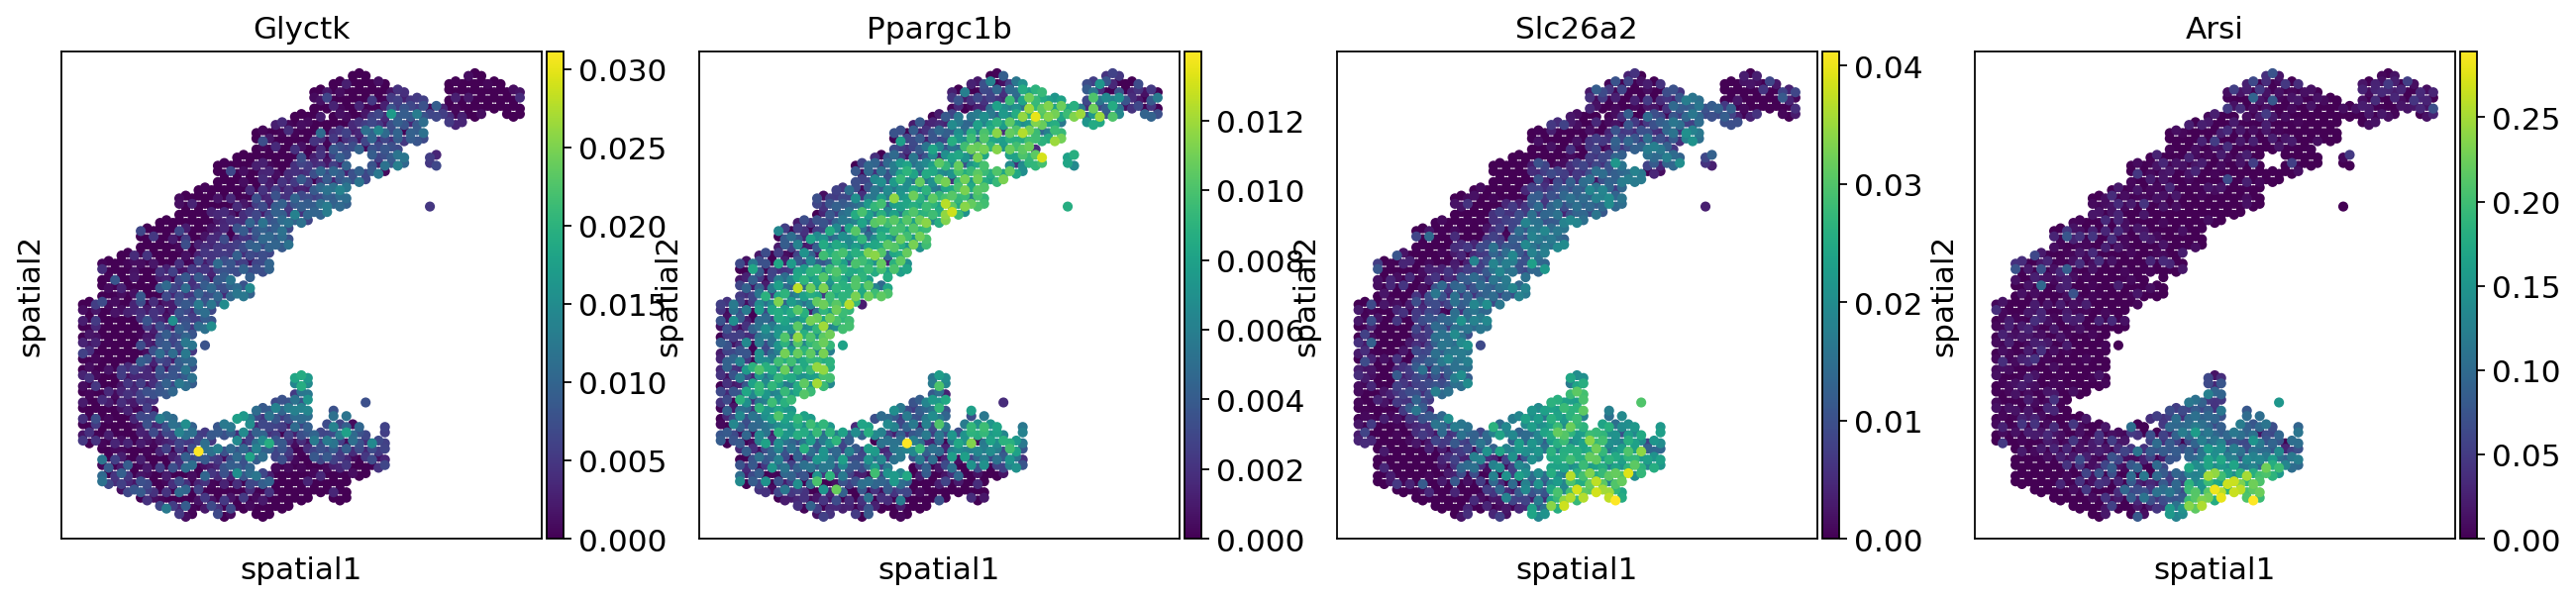

In [370]:
sc.pl.embedding(stGingival,basis="spatial",color=["Glyctk","Ppargc1b","Slc26a2","Arsi"])

In [371]:
sign_results = results_sample.query('qval < 0.05')

In [373]:
sign_results['l'].value_counts()

l
3.658758     5017
1.843280     3960
0.928643     1792
7.262334      388
0.467850       70
14.415135      14
0.235702       11
Name: count, dtype: int64

In [ ]:
histology_results, patterns = SpatialDE.aeh.spatial_patterns(stGingival.obsm["spatial"], resid_expr, sign_results, C=8, l=1.8, verbosity=1)

iter 0, ELBO: -5.26e+11
iter 1, ELBO: -2.63e+11, delta_ELBO: 2.63e+11
iter 2, ELBO: -2.63e+11, delta_ELBO: 3.34e+06
iter 3, ELBO: -2.63e+11, delta_ELBO: 3.01e+06
iter 4, ELBO: -2.63e+11, delta_ELBO: 4.85e+05
iter 5, ELBO: -2.63e+11, delta_ELBO: 1.06e+05
iter 6, ELBO: -2.63e+11, delta_ELBO: 3.21e+04
iter 7, ELBO: -2.63e+11, delta_ELBO: 1.28e+04
iter 8, ELBO: -2.63e+11, delta_ELBO: 3.05e+03
iter 9, ELBO: -2.63e+11, delta_ELBO: 1.12e+04
iter 10, ELBO: -2.63e+11, delta_ELBO: 1.77e+04
iter 11, ELBO: -2.63e+11, delta_ELBO: 2.52e+04
iter 12, ELBO: -2.63e+11, delta_ELBO: 8.79e+03
iter 13, ELBO: -2.63e+11, delta_ELBO: 6.50e+03
iter 14, ELBO: -2.63e+11, delta_ELBO: 4.14e+03


In [391]:
sample_info=pd.DataFrame(stGingival.obsm["spatial"])

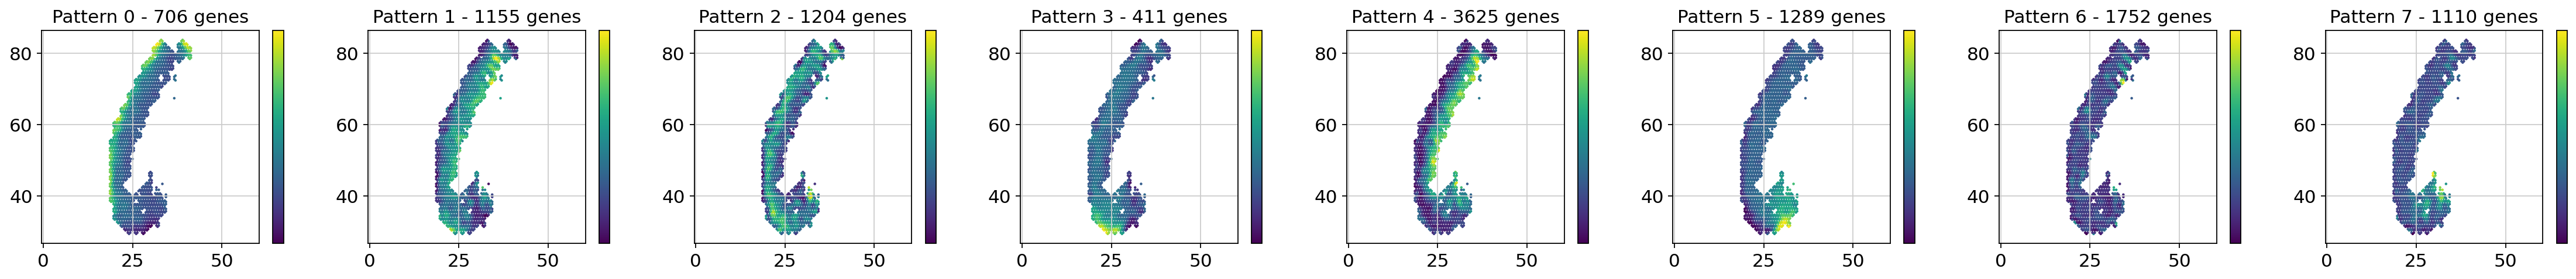

In [407]:
plt.figure(figsize=(35, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.scatter(sample_info[0], sample_info[1], c=patterns[i],s=1);
    plt.axis('equal')
    plt.title('Pattern {} - {} genes'.format(i, histology_results.query('pattern == @i').shape[0] ))
    plt.colorbar(ticks=[]);
plt.savefig("../4.6_spatial_pattern/spatialDE/4.7_pattern.pdf")

In [408]:
histology_results.to_csv("../4.6_spatial_pattern/spatialDE/histology_results.csv")
patterns.to_csv("../4.6_spatial_pattern/spatialDE/patterns.csv")

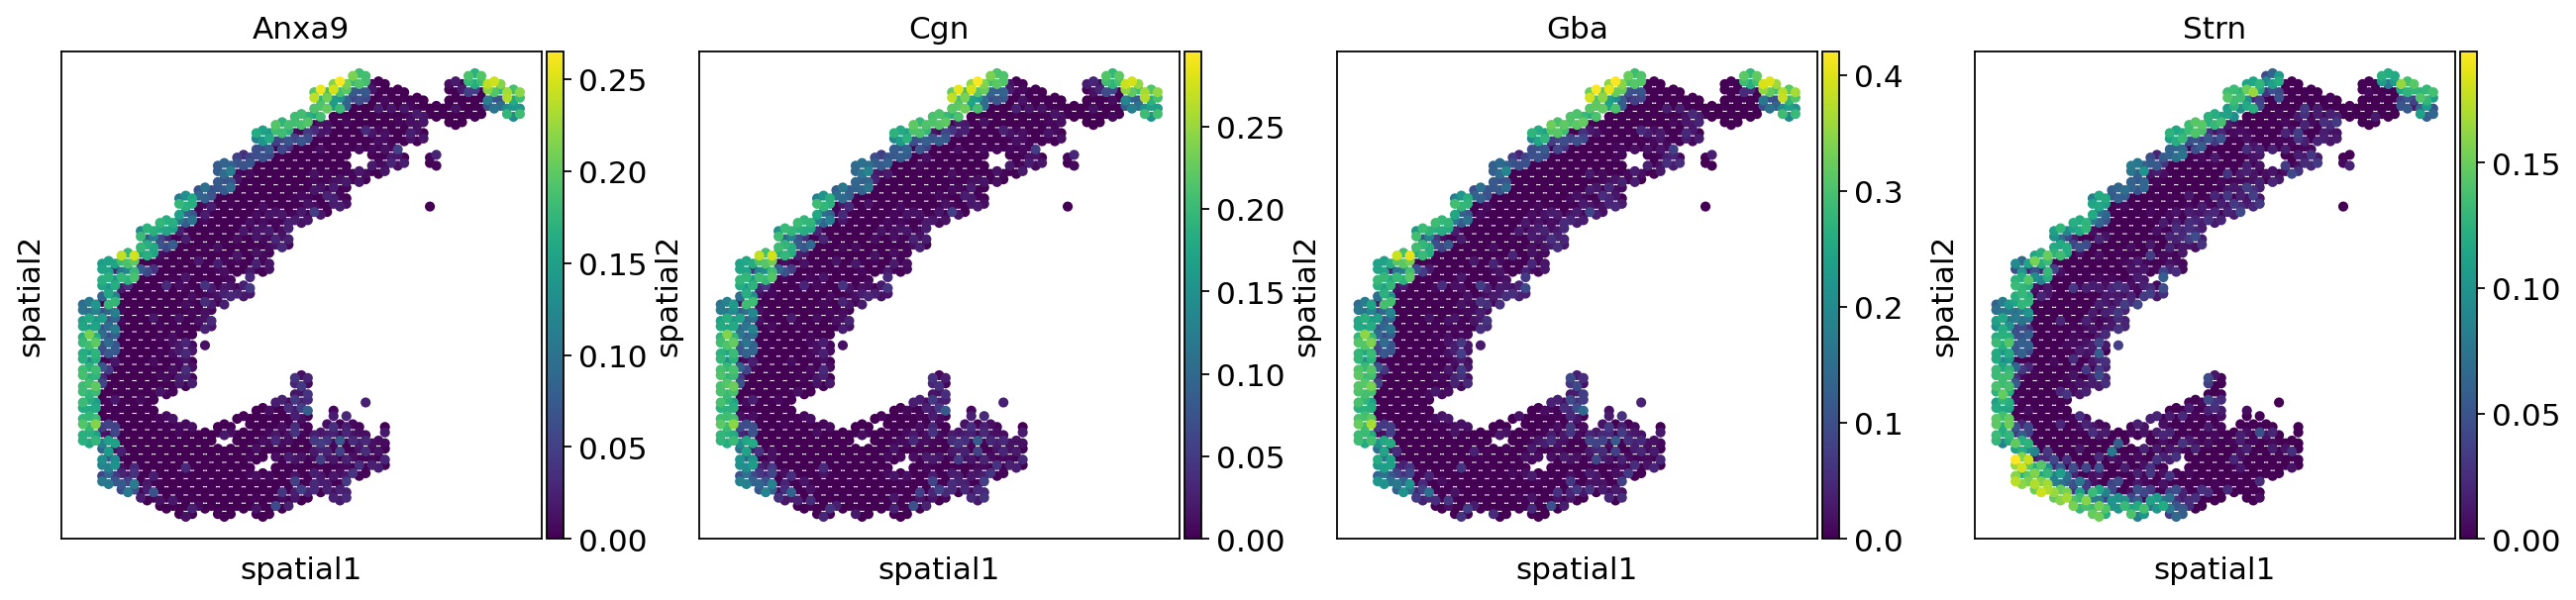

In [410]:
sc.pl.embedding(stGingival,basis="spatial",color=["Anxa9","Cgn","Gba","Strn"])

In [414]:
patterns.columns="parttern" + patterns.columns.astype("str")

In [423]:
stGingival.obs[patterns.columns] = patterns

In [431]:
histology_results=histology_results.set_index("g")
stGingival.var[[histology_results.columns]]=np.nan
stGingival.var.loc[histology_results.index,histology_results.columns] =histology_results

In [453]:
stGingival.var

,highly_variable,means,dispersions,dispersions_norm,pattern,membership
GENES,,,,,,
Samd11,False,1.000000e-12,NaN,NaN,NaN,NaN
Noc2l,False,2.384056e-02,-4.661453,0.088787,4.0,1.0
Klhl17,False,1.963421e-03,-6.490150,-1.147563,5.0,1.0
Plekhn1,True,5.111480e-02,-3.176694,1.092607,0.0,1.0
Perm1,False,1.000000e-12,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
Vbp1,False,5.613878e-03,-5.138544,-0.233766,4.0,1.0
Tmlhe,False,4.463004e-03,-5.330307,-0.363413,4.0,1.0
Spry3,False,1.000000e-12,NaN,NaN,NaN,NaN


In [454]:
stGingival.write_h5ad("../important_processed_data/4.7_gingival_st_bayes.h5ad")

## Find genes that most correlated with pattern

In [372]:
sign_results

,FSV,M,g,l,max_delta,max_ll,max_mu_hat,max_s2_t_hat,model,n,s2_FSV,s2_logdelta,time,BIC,max_ll_null,LLR,pval,qval
0,0.648430,4,Mpz,0.235702,0.542072,3600.653729,-0.009685,0.000315,SE,1447,0.033099,0.717791,0.007176,-7172.198467,3595.975159,4.678570,0.030541,0.037262
1,0.799941,4,C130074G19Rik,0.235702,0.250039,4559.083163,0.113808,0.008432,SE,1447,0.091676,3.571138,0.008229,-9089.057336,4552.500228,6.582936,0.010296,0.012568
2,0.750185,4,Dazl,0.235702,0.332935,7110.497479,0.167462,0.017154,SE,1447,0.058482,1.746451,0.007068,-14191.885968,7104.716223,5.781257,0.016198,0.019766
3,0.914358,4,Cetn3,0.235702,0.093644,6256.860160,0.171526,0.021095,SE,1447,0.183762,25.546084,0.009546,-12484.611330,6245.892434,10.967727,0.000927,0.001132
4,0.928536,4,Mettl24,0.235702,0.076948,6485.794046,0.179647,0.023417,SE,1447,0.268569,50.758884,0.011112,-12942.479100,6474.313370,11.480675,0.000703,0.000859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13301,0.781433,4,Palm,14.415135,0.148859,5741.907512,0.099597,0.000159,SE,1447,0.001935,0.067486,0.010911,-11454.706033,5460.458819,281.448693,0.000000,0.000000
13317,0.816068,4,Cactin,14.415135,0.119954,6998.991487,0.184283,0.000113,SE,1447,0.000868,0.037714,0.005190,-13968.873983,6795.112092,203.879395,0.000000,0.000000
13360,0.779503,4,Mef2b,14.415135,0.150545,6828.489680,0.199029,0.000126,SE,1447,0.001241,0.042819,0.011098,-13627.870369,6706.573732,121.915948,0.000000,0.000000
13541,0.758197,4,Get1,14.415135,0.169731,7080.238575,0.176554,0.000094,SE,1447,0.001506,0.046655,0.010719,-14131.368158,6802.305911,277.932664,0.000000,0.000000


In [282]:
stGingival.obsm["spatial"].shape

(1447, 2)

In [283]:
resid_expr

,subspot_76.5,subspot_176.4,subspot_52.2,subspot_139.6,subspot_60.6,subspot_132.3,subspot_194.1,subspot_352.2,subspot_168.4,subspot_413.3,...,subspot_292.5,subspot_56.1,subspot_357.2,subspot_107.3,subspot_284.2,subspot_182.5,subspot_60.5,subspot_394.6,subspot_374.1,subspot_406.5
GENES,,,,,,,,,,,,,,,,,,,,,
Noc2l,-5.415717,-5.905178,-6.775363,-5.508348,-7.220626,-5.289252,-5.326940,-5.674128,-5.461575,-5.543147,...,-6.798764,-5.558371,-6.721220,-5.845175,-6.685028,-6.198530,-7.079872,-5.207197,-7.069798,-6.681884
Klhl17,-5.749582,-5.685692,-5.437510,-5.852794,-5.460519,-6.124907,-5.172459,-5.827203,-5.878299,-5.829363,...,-5.616311,-5.590905,-5.481529,-5.489258,-5.468390,-5.969839,-5.742425,-5.544153,-5.833133,-5.084380
Plekhn1,-6.589488,-6.227538,-3.544102,-5.883605,-5.063054,-8.081707,-6.797173,-5.682122,-6.663240,-6.418582,...,-4.084901,-7.177387,-3.711018,-3.842553,-3.750395,-4.411238,-4.087304,-3.897839,-4.095223,-3.128671
Isg15,-5.193342,-6.139760,-5.835299,-5.990362,-5.021179,-6.661581,-5.338591,-5.700526,-5.607146,-6.743917,...,-6.335337,-5.980544,-5.963112,-5.743769,-5.985834,-6.372853,-6.369395,-6.177247,-6.326134,-5.999319
Agrn,-5.066516,-6.002433,-7.103281,-6.748932,-3.758530,-6.541421,-4.060355,-7.160569,-5.832935,-5.879289,...,-6.074307,-4.836030,-7.280133,-5.594581,-6.990117,-7.696263,-7.484747,-7.261698,-6.805510,-4.218297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mtcp1,-4.456538,-5.700910,-5.597160,-5.672592,-5.640562,-5.673446,-5.658552,-5.364392,-4.672064,-5.687052,...,-5.619535,-5.708351,-5.610143,-5.077690,-5.588853,-5.458504,-5.625163,-5.608789,-5.624237,-5.588564
Brcc3,-5.977775,-6.024850,-6.078466,-5.712144,-6.146319,-5.270962,-6.081222,-5.973706,-5.893175,-5.638668,...,-6.090938,-5.933821,-6.143816,-6.090639,-6.020389,-6.009829,-5.901150,-6.038053,-6.062116,-6.035195
Vbp1,-5.744296,-6.532125,-6.251206,-5.622446,-5.485200,-5.241771,-6.649108,-5.926031,-6.228229,-5.771486,...,-6.396228,-6.687894,-6.335350,-6.266879,-6.197364,-6.533341,-6.432704,-6.326579,-6.357804,-6.195490


In [173]:
stGingival

AnnData object with n_obs × n_vars = 1448 × 13728
    obs: 'in_tissue', 'array_row', 'array_col'
    uns: 'spatial'
    obsm: 'spatial'

## Transfer scRNA

In [490]:
gingival_1st=sc.read("../temp_data/gingivalST_1st.h5ad")

/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [496]:
gingival_2nd=sc.read("../temp_data/gingivalST_2st.h5ad")

/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [495]:
gingival_2nd

AnnData object with n_obs × n_vars = 6528 × 13072
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'seurat_clusters', 'SCT_snn_res.0.8', 'SCT_snn_res.0.2', 'cell_id', 'sample_id', 'group', 'orig.ident', 'SCT_snn_res.0.6', 'celltype', 'idents'
    var: 'features'

In [458]:
gingival_1st

AnnData object with n_obs × n_vars = 6883 × 18976
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'seurat_clusters', 'celltype', 'ident'
    uns: 'X_name'
    obsm: 'HARMONY', 'PCA', 'UMAP'
    layers: 'logcounts'

In [467]:
coord1st=pd.read_csv("../temp_data/gingival1st_coord.csv",index_col=0)
coord2nd=pd.read_csv("../temp_data/gingival2nd_coord.csv",index_col=0)

In [498]:
gingival_1st.obsm["spatial"] = np.array(coord1st[["row","col"]])
gingival_2nd.obsm["spatial"] = np.array(coord2nd[["row","col"]])

In [499]:
gingival_2nd

AnnData object with n_obs × n_vars = 6528 × 13072
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'seurat_clusters', 'SCT_snn_res.0.8', 'SCT_snn_res.0.2', 'cell_id', 'sample_id', 'group', 'orig.ident', 'SCT_snn_res.0.6', 'celltype', 'idents', 'ident'
    uns: 'X_name'
    obsm: 'spatial'
    layers: 'logcounts'

In [500]:
gingival_merge=sc.concat([gingival_1st,gingival_2nd])

/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [501]:
gingival_merge.obs=gingival_merge.obs[['nCount_RNA', 'nFeature_RNA', 'percent.mt','orig.ident','celltype', 'idents']]

In [502]:
gingival_merge.obs["celltype"]=gingival_merge.obs["celltype"].astype("str")

In [503]:
gingival_merge.write_h5ad("../important_processed_data/4.7_scMerge.h5ad")

In [505]:
gingival_merge.X[1:10,1:10].toarray()

array([[0., 0., 0., 1., 0., 1., 1., 1., 0.],
       [0., 0., 1., 0., 0., 1., 1., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 2., 1., 0., 0., 1., 6.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 4., 0., 0., 1., 1., 0.],
       [0., 0., 0., 1., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1.]])

In [506]:
sc.pp.calculate_qc_metrics(gingival_merge, inplace=True)

In [507]:
counts = sc.get.obs_df(gingival_merge, keys=list(gingival_merge.var_names), use_raw=False)

In [513]:
total_counts = sc.get.obs_df(gingival_merge, keys=["total_counts"])

In [509]:
norm_expr = NaiveDE.stabilize(counts.T).T

In [515]:
resid_expr = NaiveDE.regress_out(total_counts, norm_expr.T, "np.log(total_counts)").T

In [516]:


results = SpatialDE.run(gingival_merge.obsm["spatial"], resid_expr)

Models:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/12787 [00:00<?, ?it/s]

  0%|          | 0/12787 [00:00<?, ?it/s]

  0%|          | 0/12787 [00:00<?, ?it/s]

  0%|          | 0/12787 [00:00<?, ?it/s]

...

  0%|          | 0/12787 [00:00<?, ?it/s]

  0%|          | 0/12787 [00:00<?, ?it/s]

  0%|          | 0/12787 [00:00<?, ?it/s]

  0%|          | 0/12787 [00:00<?, ?it/s]

/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/SpatialDE/base.py:310: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  model_results = model_results[model_results.groupby(['g'])['max_ll'].transform(max) == model_results['max_ll']]
/home/zhanglab/mambaforge/envs/celloracle/lib/python3.9/site-packages/SpatialDE/util.py:19: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  pv = pv.ravel()  # flattens the array in place, more efficient than flatten()


In [519]:
results

,FSV,M,g,l,max_delta,max_ll,max_mu_hat,max_s2_t_hat,model,n,s2_FSV,s2_logdelta,time,BIC,max_ll_null,LLR,pval,qval
0,2.059228e-09,4,Lonrf2,0.235702,4.851652e+08,19355.032865,-2.114932,9.225629e-09,SE,13056,5.046977e-08,8.617835e+09,0.029835,-38672.157717,19355.032836,0.000029,0.995698,0.720957
1,2.059228e-09,4,Chst10,0.235702,4.851652e+08,11929.295793,-2.129555,9.366750e-09,SE,13056,3.906325e-05,6.670144e+12,0.023196,-23820.683573,11929.295774,0.000019,0.996541,0.720957
2,2.059228e-09,4,Cdk15,0.235702,4.851652e+08,6925.804362,-2.135547,9.441786e-09,SE,13056,1.183531e-03,2.020907e+14,0.029104,-13813.700712,6925.804343,0.000019,0.996514,0.720957
3,2.059228e-09,4,Thsd7b,0.235702,4.851652e+08,10391.785014,-2.118348,9.273778e-09,SE,13056,3.948952e-05,6.742931e+12,0.049270,-20745.662016,10391.784995,0.000019,0.996541,0.720957
4,2.059228e-09,4,Nr5a2,0.235702,4.851652e+08,15176.826028,-2.107709,9.168349e-09,SE,13056,1.796922e-04,3.068288e+13,0.034235,-30315.744043,15176.826009,0.000019,0.996524,0.720957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12782,6.998172e-02,4,Marco,56.794163,1.020039e+00,407820.488691,-2.106036,5.453910e-04,SE,13056,1.903213e-03,3.729407e-01,0.026056,-815603.069370,443586.198653,-35765.709961,1.000000,0.722325
12783,6.998172e-02,4,Prnd,56.794163,1.020039e+00,407820.488691,-2.106036,5.453910e-04,SE,13056,1.903213e-03,3.729407e-01,0.041759,-815603.069370,443586.198653,-35765.709961,1.000000,0.722325
12784,6.998172e-02,4,Lime1,56.794163,1.020039e+00,407820.488691,-2.106036,5.453910e-04,SE,13056,1.903213e-03,3.729407e-01,0.025743,-815603.069370,443586.198653,-35765.709961,1.000000,0.722325
12785,6.998172e-02,4,Sucnr1,56.794163,1.020039e+00,407820.488691,-2.106036,5.453910e-04,SE,13056,1.903213e-03,3.729407e-01,0.025979,-815603.069370,443586.198653,-35765.709961,1.000000,0.722325


In [520]:
top10 = results.sort_values("qval").head(10)[["g", "l", "qval"]]
top10

,g,l,qval
6393,Dtnbp1,1.843280,0.0
10805,Fam210a,3.658758,0.0
5926,Ccm2,1.843280,0.0
5924,Purb,1.843280,0.0
5923,Zmiz2,1.843280,0.0
5919,Ewsr1,1.843280,0.0
5917,Ap1b1,1.843280,0.0
5914,Slc35e4,1.843280,0.0
11825,Rb1,7.262334,0.0
5909,Pla2g3,1.843280,0.0


In [526]:
gingival_merge

AnnData object with n_obs × n_vars = 13056 × 12787
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'orig.ident', 'celltype', 'idents', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'
    layers: 'logcounts'

In [529]:
sign_results = results.query('qval < 0.05')

In [530]:
sign_results['l'].value_counts()

l
1.843280     4749
3.658758     3068
0.928643     1432
7.262334      703
0.467850      538
14.415135     237
28.612856      40
0.235702       18
56.794163       4
Name: count, dtype: int64

In [ ]:
histology_results_sc, patterns_sc = SpatialDE.aeh.spatial_patterns(gingival_merge.obsm["spatial"], 
                                                                   resid_expr, sign_results, C=8, l=1.8, verbosity=1)

iter 0, ELBO: -9.73e+12


In [533]:
resid_expr

,Xkr4,Rp1,Sox17,Lypla1,Tcea1,Rgs20,Atp6v1h,Rb1cc1,Pcmtd1,Rrs1,...,Gjd3,Cd300e,Matn3,Ak7,Tex22,Acr,Cpn2,Tm4sf19,Trat1,Cc2d2b
UCID0000,-2.764171,-2.119341,-2.137751,-5.382127,-9.115822,-4.685103,-5.991153,-7.668321,-4.798984,-5.765093,...,-2.119097,-2.104221,-2.191515,-2.540261,-2.134512,-2.107662,-2.107803,-2.168181,-2.103789,-2.113599
UCID0001,-2.781557,-2.119692,-2.138588,-7.748236,-7.080096,-4.753232,-6.152452,-5.594358,-6.264576,-8.141318,...,-2.119442,-2.104174,-2.193773,-2.551732,-2.135264,-2.107705,-2.107850,-2.169822,-2.103730,-2.113799
UCID0002,-2.729402,-2.118638,-2.136075,-5.091720,-8.745493,-4.548850,-5.668571,-5.153566,-5.772038,-7.675352,...,-2.118407,-2.104317,-2.186999,-2.517321,-2.133008,-2.107576,-2.107710,-2.164897,-2.103908,-2.113199
UCID0003,-2.620032,-2.116427,-2.130805,-6.399123,-7.580600,-4.120258,-6.874765,-4.229220,-6.960079,-6.698215,...,-2.116237,-2.104619,-2.172794,-2.445161,-2.128275,-2.107306,-2.107416,-2.154570,-2.104281,-2.111942
UCID0004,-2.825400,-2.120579,-2.140701,-5.893532,-6.909705,-2.704144,-8.780116,-8.185801,-6.678619,-4.615146,...,-2.120312,-2.104053,-2.199468,-2.580659,-2.137161,-2.107814,-2.107968,-2.173962,-2.103580,-2.114303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UCID6523,-2.860627,-2.121291,-2.142399,-5.164240,-10.143170,-2.204826,-6.248682,-6.262626,-5.709886,-8.847753,...,-2.121012,-2.103956,-2.204043,-2.603901,-2.138686,-2.107901,-2.108063,-2.177289,-2.103460,-2.114707
UCID6524,-2.855117,-2.121179,-2.142133,-4.840338,-6.562184,-5.041499,-6.197567,-6.216064,-6.959265,-4.729346,...,-2.120902,-2.103971,-2.203327,-2.600266,-2.138447,-2.107887,-2.108048,-2.176768,-2.103479,-2.114644
UCID6525,-2.868500,-2.121450,-2.142778,-5.616161,-6.982612,-5.093943,-5.935574,-5.305650,-9.306548,-5.673678,...,-2.121168,-2.103934,-2.205066,0.249167,-2.139026,-2.107920,-2.108084,0.042866,-2.103433,-2.114798
UCID6526,-2.817129,-2.120411,-2.140303,-8.045353,-9.679879,-4.892633,-5.845122,-8.115902,-8.821413,-8.459134,...,-2.120148,-2.104076,-2.198394,-2.575202,-2.136803,-2.107793,-2.107946,-2.173181,-2.103608,-2.114208


In [534]:
gingival_merge

AnnData object with n_obs × n_vars = 13056 × 12787
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'orig.ident', 'celltype', 'idents', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'
    layers: 'logcounts'

In [540]:
coord=stGingival.obs[["array_row","array_col"]]
coord["point"] = coord.index

/tmp/ipykernel_1544215/511774775.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coord["point"] = coord.index


In [544]:
gingival_merge_coord = pd.DataFrame(gingival_merge.obsm["spatial"])

In [546]:
gingival_merge_coord.columns = ["array_row","array_col"]

In [541]:
coord

,array_row,array_col,point
subspot_76.5,25.000000,37.666667,subspot_76.5
subspot_176.4,33.666667,37.666667,subspot_176.4
subspot_52.2,29.333333,74.666667,subspot_52.2
subspot_139.6,29.000000,68.333333,subspot_139.6
subspot_60.6,26.000000,29.333333,subspot_60.6
...,...,...,...
subspot_182.5,24.000000,68.666667,subspot_182.5
subspot_60.5,26.000000,30.666667,subspot_60.5
subspot_394.6,21.000000,48.333333,subspot_394.6
subspot_374.1,28.333333,76.333333,subspot_374.1


In [547]:
gingival_merge_coord_point =  pd.merge(gingival_merge_coord, coord, on=['array_row', 'array_col'], how='left')

In [603]:
gingival_merge.obs["point"] = np.array(gingival_merge_coord_point["point"].astype("str"))

In [604]:
gingival_merge.obs["point"] 

UCID0000    subspot_206.3
UCID0001     subspot_98.4
UCID0002      subspot_1.1
UCID0003    subspot_384.2
UCID0004    subspot_116.2
                ...      
UCID6523     subspot_41.4
UCID6524    subspot_409.6
UCID6525    subspot_338.2
UCID6526    subspot_215.5
UCID6527      subspot_5.4
Name: point, Length: 13056, dtype: object

In [552]:
arr =gingival_merge_coord_point["point"]

# Dictionary to store indices for each unique element
indices = {}

# Populate dictionary with indices
for i, element in enumerate(arr):
    if element not in indices:
        indices[element] = [i]
    else:
        indices[element].append(i)

# Randomly select indices for each unique element
selected_indices = {}
for element, index_list in indices.items():
    selected_index = random.choice(index_list)
    selected_indices[element] = selected_index

# Output selected indices
print(selected_indices)

{'subspot_206.3': 0, 'subspot_98.4': 12280, 'subspot_1.1': 146, 'subspot_384.2': 8935, 'subspot_116.2': 2486, 'subspot_194.2': 7657, 'subspot_242.3': 8627, 'subspot_388.3': 7946, 'subspot_285.1': 6629, 'subspot_413.6': 12233, 'subspot_160.5': 10, 'subspot_273.4': 10868, 'subspot_315.5': 5013, 'subspot_129.2': 13, 'subspot_2.1': 7088, 'subspot_249.2': 11210, 'subspot_388.1': 4201, 'subspot_206.2': 12336, 'subspot_193.2': 12400, 'subspot_119.4': 12241, 'subspot_230.6': 20, 'subspot_76.3': 21, 'subspot_325.6': 22, 'subspot_153.2': 1878, 'subspot_12.3': 1479, 'subspot_123.6': 3608, 'subspot_130.3': 6762, 'subspot_208.4': 12127, 'subspot_356.5': 28, 'subspot_414.1': 9927, 'subspot_296.2': 30, 'subspot_377.3': 10524, 'subspot_21.6': 152, 'subspot_123.1': 6717, 'subspot_31.5': 10254, 'subspot_324.1': 8164, 'subspot_291.5': 10028, 'subspot_325.1': 11103, 'subspot_314.4': 9552, 'subspot_344.5': 2445, 'subspot_79.2': 12368, 'subspot_163.3': 9888, 'subspot_52.2': 9570, 'subspot_132.4': 1562, 'sub

In [557]:
indice = selected_indices.values()

In [567]:
indice= list(indice)

In [569]:
gingival_merge.obs.iloc[indice,:]

,nCount_RNA,nFeature_RNA,percent.mt,orig.ident,celltype,idents,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,point
UCID0000,10067.0,3115,9.367239,D0,GE2,gingiva progenitor,2739,7.915713,6603.0,8.795431,26.291080,32.939573,41.602302,56.958958,NaN
UCID5752,9741.0,3024,3.481862,D3_K5_GFP,GE_keratini,cornified,3024,8.014666,9741.0,9.184202,32.501797,38.948773,47.233344,61.749307,NaN
UCID0146,25819.0,4941,2.017894,D0,GE5,basal layer,4360,8.380457,16290.0,9.698368,32.406384,37.796194,45.033763,57.894414,NaN
UCID2407,4636.0,2424,3.313040,D3_K5_GFP,GE_keratini,basal layer,2424,7.793587,4636.0,8.441823,18.205349,24.611734,33.692839,50.323555,NaN
UCID2486,30940.0,4660,1.208791,D0,GE2,gingiva progenitor,4095,8.317766,18843.0,9.843950,35.312848,42.694900,50.708486,63.970705,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UCID5960,17594.0,2756,0.363760,D0,GE4,stratum corneum,2384,7.776954,13055.0,9.477003,51.007277,58.460360,66.365377,78.284182,NaN
UCID5282,12385.0,3193,1.722133,D3_K5_GFP,GE_keratini,spinous+granular,3192,8.068716,12384.0,9.424241,43.750000,50.032300,57.227067,69.089147,NaN
UCID5859,35378.0,4123,0.920380,D0_K5_GFP,GE_keratini,stratum corneum,4123,8.324579,35378.0,10.473874,49.208548,57.764713,65.591611,75.970942,NaN
UCID5542,24596.0,3474,0.316203,D5_K5_GFP,GE_JE,IBL,3474,8.153350,24596.0,10.110380,53.081802,59.928444,67.031225,77.150756,NaN


In [605]:
gingival_merge_subset = gingival_merge[indice]

In [574]:
histology_results_sc, patterns_sc = SpatialDE.aeh.spatial_patterns(gingival_merge_subset.obsm["spatial"], 
                                                                   resid_expr.iloc[indice], sign_results, C=8, l=1.8, verbosity=1)

iter 0, ELBO: -5.29e+11
iter 1, ELBO: -2.63e+11, delta_ELBO: 2.66e+11
iter 2, ELBO: -2.63e+11, delta_ELBO: 2.29e+06
iter 4, ELBO: -2.63e+11, delta_ELBO: 4.35e+04
iter 5, ELBO: -2.63e+11, delta_ELBO: 1.16e+04
iter 6, ELBO: -2.63e+11, delta_ELBO: 3.35e+03
iter 7, ELBO: -2.63e+11, delta_ELBO: 1.38e+03
iter 8, ELBO: -2.63e+11, delta_ELBO: 6.98e+02
iter 9, ELBO: -2.63e+11, delta_ELBO: 4.36e+02
iter 10, ELBO: -2.63e+11, delta_ELBO: 2.88e+02
iter 11, ELBO: -2.63e+11, delta_ELBO: 2.71e+02
iter 12, ELBO: -2.63e+11, delta_ELBO: 1.37e+02
iter 13, ELBO: -2.63e+11, delta_ELBO: 1.36e+01
iter 14, ELBO: -2.63e+11, delta_ELBO: 3.07e+02
iter 15, ELBO: -2.63e+11, delta_ELBO: 6.24e+02
iter 16, ELBO: -2.63e+11, delta_ELBO: 5.24e+02
iter 17, ELBO: -2.63e+11, delta_ELBO: 3.15e+02
iter 18, ELBO: -2.63e+11, delta_ELBO: 1.20e+02
iter 19, ELBO: -2.63e+11, delta_ELBO: 4.37e+01
iter 20, ELBO: -2.63e+11, delta_ELBO: 1.54e+01
iter 21, ELBO: -2.63e+11, delta_ELBO: 4.06e+00
iter 22, ELBO: -2.63e+11, delta_ELBO: 1.12e+

In [578]:
gingival_merge.obsm["spatial"]

array([[29.66666667, 72.33333333],
       [19.66666667, 49.66666667],
       [35.33333333, 79.33333333],
       ...,
       [26.33333333, 59.66666667],
       [27.        , 31.66666667],
       [27.66666667, 41.66666667]])

In [586]:
sample_info_sc = gingival_merge_subset.obsm["spatial"].T

In [587]:
sample_info_sc[0]

ArrayView([29.66666667, 19.66666667, 35.33333333, ..., 28.33333333,
           26.        , 21.        ])

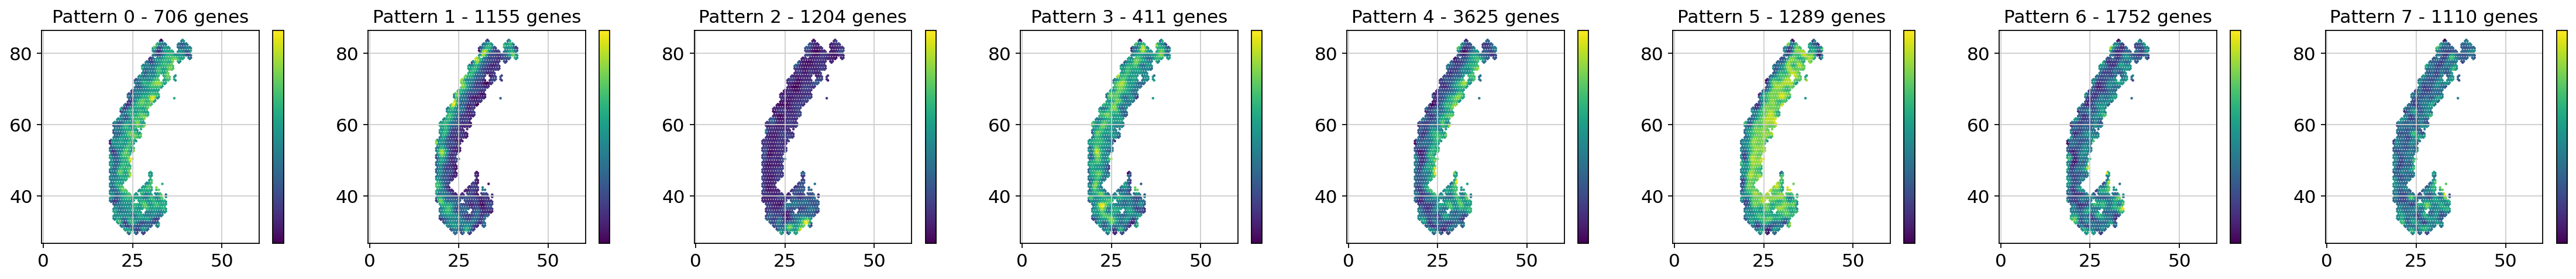

In [588]:
plt.figure(figsize=(35, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.scatter(sample_info_sc[0], sample_info_sc[1], c=patterns_sc[i],s=1);
    plt.axis('equal')
    plt.title('Pattern {} - {} genes'.format(i, histology_results.query('pattern == @i').shape[0] ))
    plt.colorbar(ticks=[]);
plt.savefig("../4.6_spatial_pattern/spatialDE/4.8_pattern.pdf")

In [589]:
patterns_sc.columns="parttern" + patterns_sc.columns.astype("str")

In [610]:
patterns_sc.index = gingival_merge_subset.obs_names

In [611]:
gingival_merge_subset.obs[patterns_sc.columns]=np.nan
gingival_merge_subset.obs[patterns_sc.columns] = patterns_sc

In [657]:
gingival_merge_subset.obs

,nCount_RNA,nFeature_RNA,percent.mt,orig.ident,celltype,idents,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,...,pct_counts_in_top_500_genes,point,parttern0,parttern1,parttern2,parttern3,parttern4,parttern5,parttern6,parttern7
UCID0000,10067.0,3115,9.367239,D0,GE2,gingiva progenitor,2739,7.915713,6603.0,8.795431,...,56.958958,subspot_206.3,-0.048687,-0.085362,-0.198657,0.034252,-0.067630,0.049312,-0.124799,-0.096519
UCID5752,9741.0,3024,3.481862,D3_K5_GFP,GE_keratini,cornified,3024,8.014666,9741.0,9.184202,...,61.749307,subspot_98.4,-0.126176,0.405736,-0.099904,0.024800,-0.251670,-0.495776,0.000191,0.002794
UCID0146,25819.0,4941,2.017894,D0,GE5,basal layer,4360,8.380457,16290.0,9.698368,...,57.894414,subspot_1.1,0.172014,-0.231545,0.005340,-0.123107,0.367119,0.147133,0.298344,0.155546
UCID2407,4636.0,2424,3.313040,D3_K5_GFP,GE_keratini,basal layer,2424,7.793587,4636.0,8.441823,...,50.323555,subspot_384.2,0.131949,-0.232624,-0.026303,-0.037165,0.214719,0.231481,0.075094,-0.009950
UCID2486,30940.0,4660,1.208791,D0,GE2,gingiva progenitor,4095,8.317766,18843.0,9.843950,...,63.970705,subspot_116.2,0.161537,-0.014842,-0.217719,0.247004,0.009819,0.235763,-0.011147,-0.007870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UCID5960,17594.0,2756,0.363760,D0,GE4,stratum corneum,2384,7.776954,13055.0,9.477003,...,78.284182,subspot_292.5,-0.154597,0.254842,-0.146904,-0.080250,-0.245493,-0.468279,0.051087,-0.032353
UCID5282,12385.0,3193,1.722133,D3_K5_GFP,GE_keratini,spinous+granular,3192,8.068716,12384.0,9.424241,...,69.089147,subspot_394.6,-0.062535,-0.141626,-0.240144,0.011192,-0.181005,0.091014,-0.194470,-0.094717
UCID5859,35378.0,4123,0.920380,D0_K5_GFP,GE_keratini,stratum corneum,4123,8.324579,35378.0,10.473874,...,75.970942,subspot_374.1,-0.099064,0.210406,0.060981,-0.064157,-0.173609,-0.553063,0.195685,0.028248
UCID5542,24596.0,3474,0.316203,D5_K5_GFP,GE_JE,IBL,3474,8.153350,24596.0,10.110380,...,77.150756,subspot_60.5,-0.338347,0.077111,1.134896,-0.361792,-0.444541,-0.878258,0.062063,0.066778


In [656]:
patterns_sc.columns

Index(['parttern0', 'parttern1', 'parttern2', 'parttern3', 'parttern4',
       'parttern5', 'parttern6', 'parttern7', 'point'],
      dtype='object')

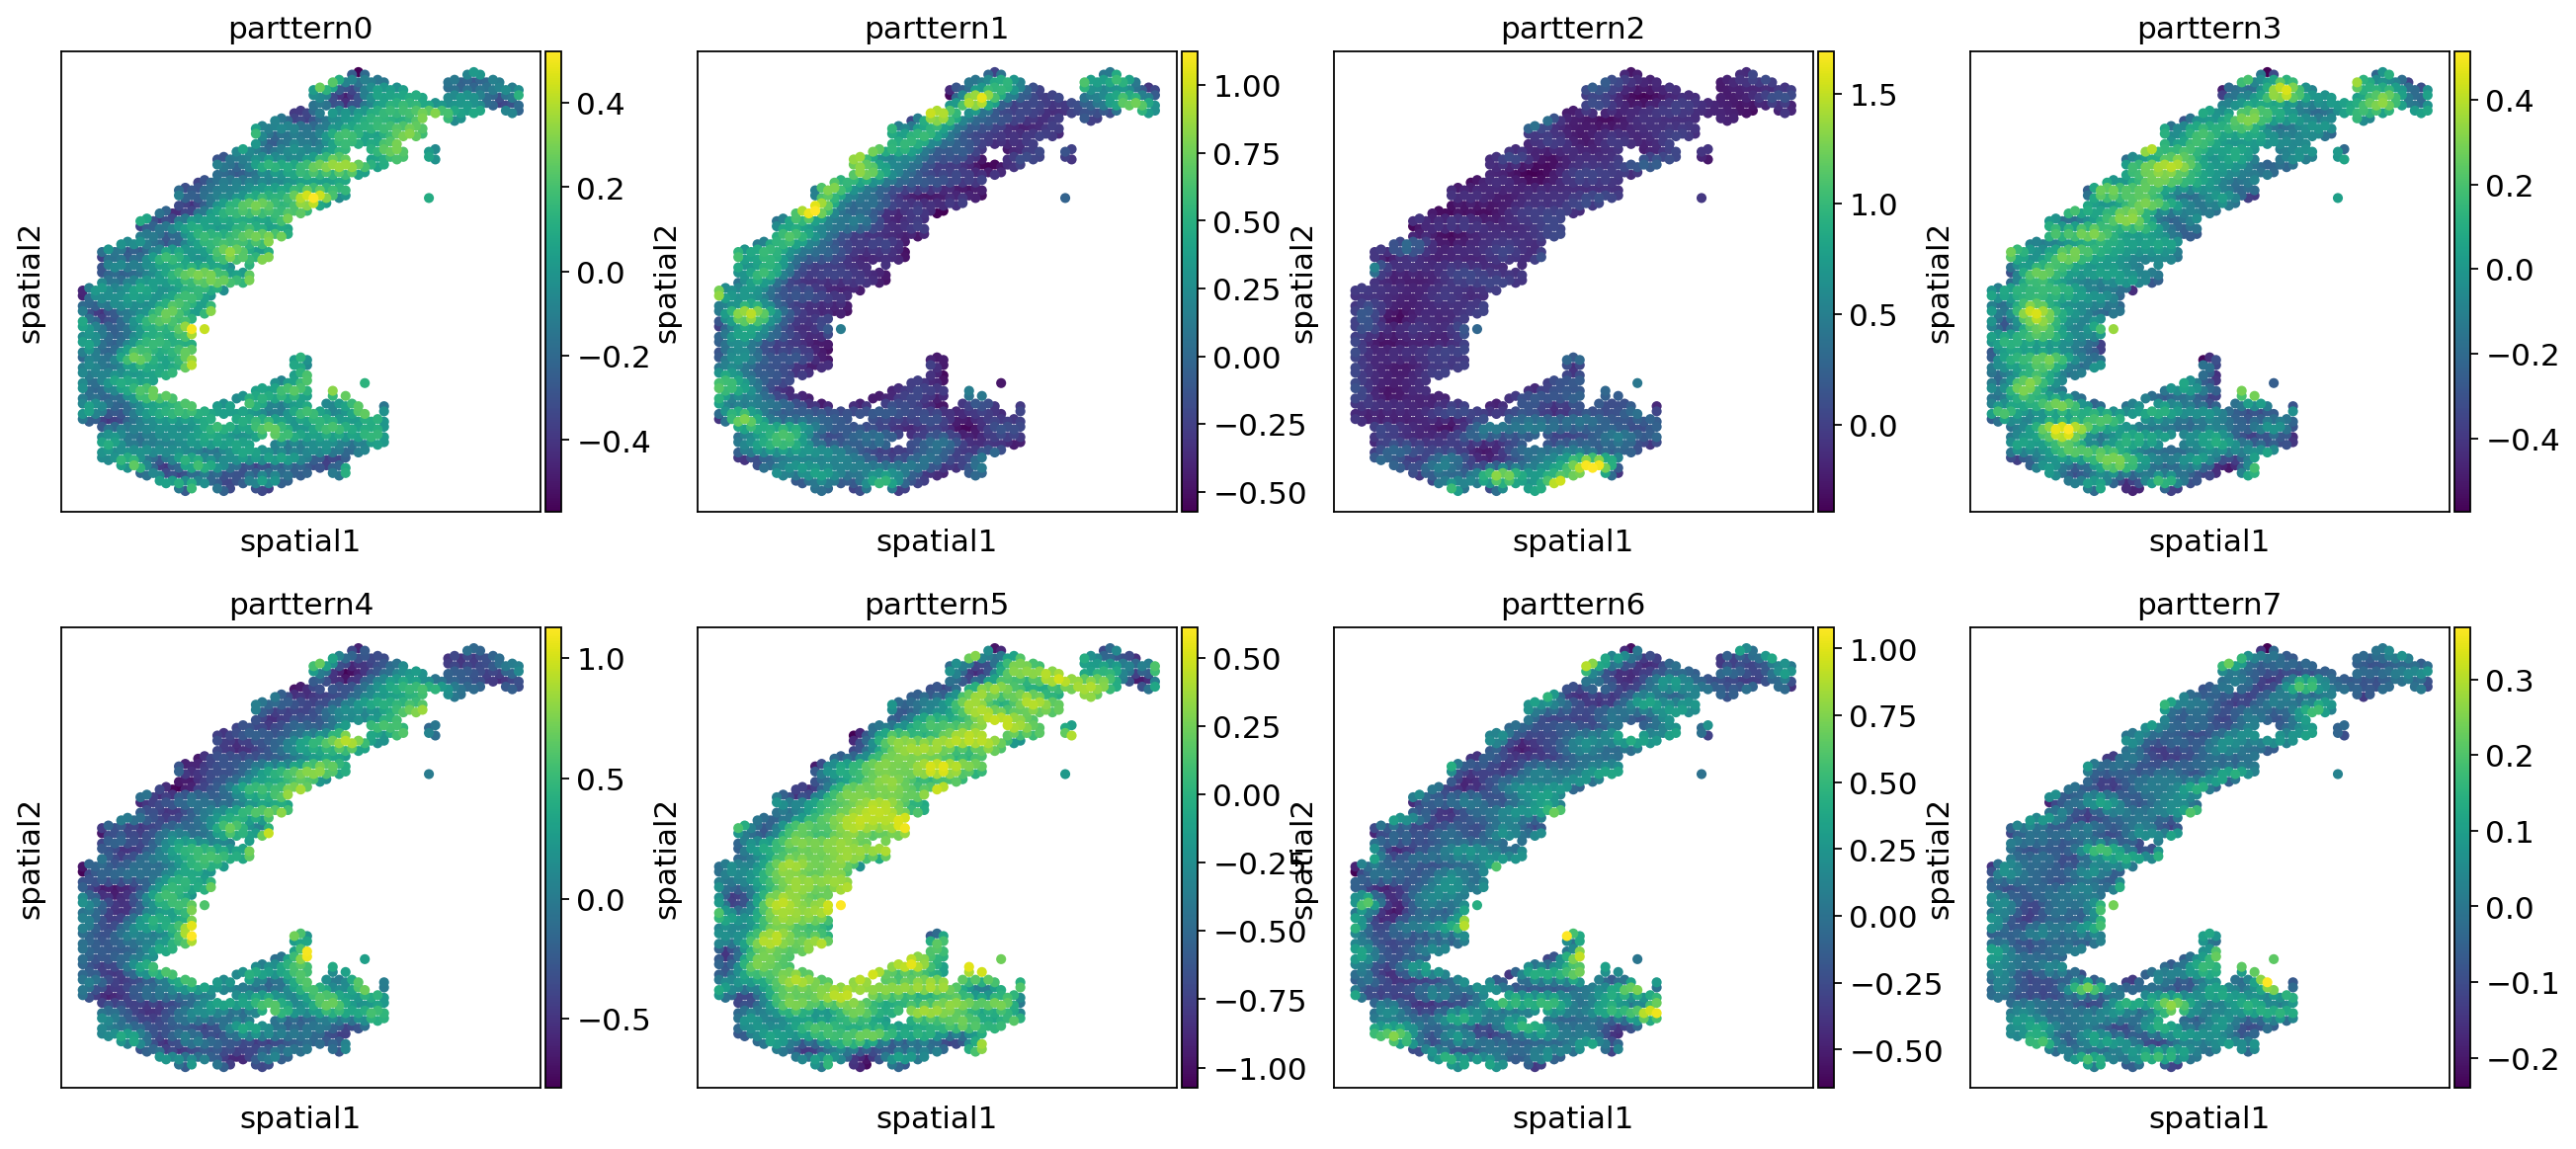

In [659]:
sc.pl.embedding(gingival_merge_subset,basis="spatial", color=['parttern0', 'parttern1', 'parttern2', 'parttern3', 'parttern4',
       'parttern5', 'parttern6', 'parttern7'],)


In [614]:

gingival_merge_subset.var[[histology_results_sc.columns]]=np.nan
gingival_merge_subset.var.loc[histology_results_sc.index,histology_results_sc.columns] =histology_results_sc

In [615]:
patterns_sc.index = gingival_merge_subset.obs["point"]

In [593]:
gingival_merge_subset

AnnData object with n_obs × n_vars = 1447 × 12787
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'orig.ident', 'celltype', 'idents', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'point', 'parttern0', 'parttern1', 'parttern2', 'parttern3', 'parttern4', 'parttern5', 'parttern6', 'parttern7'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'pattern', 'membership'
    obsm: 'spatial'
    layers: 'logcounts'

In [620]:
patterns_sc["point"] = patterns_sc.index

In [624]:
patterns_sc.index.name=""

In [625]:
patternLong =  pd.merge( gingival_merge.obs,patterns_sc, on=['point'], how='left')

In [646]:
patternLong.index =  gingival_merge.obs_names
gingival_merge.obs["point"] = patternLong["point"]

In [650]:
gingival_merge.obs[patterns_sc.columns] = patternLong[patterns_sc.columns]

In [651]:
 patternLong[patterns_sc.columns].index =  gingival_merge.obs_names
gingival_merge.obs[patterns_sc.columns] 

,parttern0,parttern1,parttern2,parttern3,parttern4,parttern5,parttern6,parttern7,point
UCID0000,-0.048687,-0.085362,-0.198657,0.034252,-0.067630,0.049312,-0.124799,-0.096519,subspot_206.3
UCID0001,-0.126176,0.405736,-0.099904,0.024800,-0.251670,-0.495776,0.000191,0.002794,subspot_98.4
UCID0002,0.172014,-0.231545,0.005340,-0.123107,0.367119,0.147133,0.298344,0.155546,subspot_1.1
UCID0003,0.131949,-0.232624,-0.026303,-0.037165,0.214719,0.231481,0.075094,-0.009950,subspot_384.2
UCID0004,0.161537,-0.014842,-0.217719,0.247004,0.009819,0.235763,-0.011147,-0.007870,subspot_116.2
...,...,...,...,...,...,...,...,...,...
UCID6523,-0.349339,0.851751,-0.183667,-0.007472,-0.528909,-0.610122,-0.329297,-0.066687,subspot_41.4
UCID6524,-0.057934,-0.019625,-0.299023,0.220499,-0.236980,0.277263,-0.300544,-0.122436,subspot_409.6
UCID6525,0.302954,-0.402368,-0.010334,-0.083280,0.581742,0.243714,0.234462,0.061660,subspot_338.2
UCID6526,-0.301000,0.276406,0.954735,-0.144725,-0.406943,-0.644165,-0.056290,0.027351,subspot_215.5


In [652]:
gingival_merge.obs

,nCount_RNA,nFeature_RNA,percent.mt,orig.ident,celltype,idents,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,...,pct_counts_in_top_500_genes,point,parttern0,parttern1,parttern2,parttern3,parttern4,parttern5,parttern6,parttern7
UCID0000,10067.0,3115,9.367239,D0,GE2,gingiva progenitor,2739,7.915713,6603.0,8.795431,...,56.958958,subspot_206.3,-0.048687,-0.085362,-0.198657,0.034252,-0.067630,0.049312,-0.124799,-0.096519
UCID0001,13301.0,2510,6.841591,D0,GE4,cornified,2188,7.691200,8330.0,9.027739,...,75.750300,subspot_98.4,-0.126176,0.405736,-0.099904,0.024800,-0.251670,-0.495776,0.000191,0.002794
UCID0002,7941.0,2644,12.542501,D0,GE3,basal layer,2299,7.740664,4149.0,8.330864,...,51.072548,subspot_1.1,0.172014,-0.231545,0.005340,-0.123107,0.367119,0.147133,0.298344,0.155546
UCID0003,2581.0,897,17.551337,D0,GE3,basal layer,754,6.626718,962.0,6.870053,...,73.596674,subspot_384.2,0.131949,-0.232624,-0.026303,-0.037165,0.214719,0.231481,0.075094,-0.009950
UCID0004,27614.0,3668,4.867096,D0,GE2,gingiva progenitor,3163,8.059592,14966.0,9.613603,...,70.686890,subspot_116.2,0.161537,-0.014842,-0.217719,0.247004,0.009819,0.235763,-0.011147,-0.007870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UCID6523,23964.0,3434,0.624623,D0_K5_GFP,GE_keratini,stratum corneum,3434,8.141772,23964.0,10.084350,...,77.036388,subspot_41.4,-0.349339,0.851751,-0.183667,-0.007472,-0.528909,-0.610122,-0.329297,-0.066687
UCID6524,22263.0,4454,1.006797,D5_K5_GFP,GE_keratini,gingiva progenitor,4454,8.401782,22263.0,10.010726,...,63.540403,subspot_409.6,-0.057934,-0.019625,-0.299023,0.220499,-0.236980,0.277263,-0.300544,-0.122436
UCID6525,26629.0,5320,1.978408,D3_K5_GFP,GE_prolifer1,basal layer,5314,8.578288,26623.0,10.189568,...,49.633775,subspot_338.2,0.302954,-0.402368,-0.010334,-0.083280,0.581742,0.243714,0.234462,0.061660
UCID6526,13403.0,2394,0.346976,D0_K5_GFP,GE_JE,JE_progenitor,2391,7.779885,13400.0,9.503085,...,78.126866,subspot_215.5,-0.301000,0.276406,0.954735,-0.144725,-0.406943,-0.644165,-0.056290,0.027351


In [649]:
patternLong

,nCount_RNA,nFeature_RNA,percent.mt,orig.ident,celltype,idents,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,...,pct_counts_in_top_500_genes,point,parttern0,parttern1,parttern2,parttern3,parttern4,parttern5,parttern6,parttern7
UCID0000,10067.0,3115,9.367239,D0,GE2,gingiva progenitor,2739,7.915713,6603.0,8.795431,...,56.958958,subspot_206.3,-0.048687,-0.085362,-0.198657,0.034252,-0.067630,0.049312,-0.124799,-0.096519
UCID0001,13301.0,2510,6.841591,D0,GE4,cornified,2188,7.691200,8330.0,9.027739,...,75.750300,subspot_98.4,-0.126176,0.405736,-0.099904,0.024800,-0.251670,-0.495776,0.000191,0.002794
UCID0002,7941.0,2644,12.542501,D0,GE3,basal layer,2299,7.740664,4149.0,8.330864,...,51.072548,subspot_1.1,0.172014,-0.231545,0.005340,-0.123107,0.367119,0.147133,0.298344,0.155546
UCID0003,2581.0,897,17.551337,D0,GE3,basal layer,754,6.626718,962.0,6.870053,...,73.596674,subspot_384.2,0.131949,-0.232624,-0.026303,-0.037165,0.214719,0.231481,0.075094,-0.009950
UCID0004,27614.0,3668,4.867096,D0,GE2,gingiva progenitor,3163,8.059592,14966.0,9.613603,...,70.686890,subspot_116.2,0.161537,-0.014842,-0.217719,0.247004,0.009819,0.235763,-0.011147,-0.007870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UCID6523,23964.0,3434,0.624623,D0_K5_GFP,GE_keratini,stratum corneum,3434,8.141772,23964.0,10.084350,...,77.036388,subspot_41.4,-0.349339,0.851751,-0.183667,-0.007472,-0.528909,-0.610122,-0.329297,-0.066687
UCID6524,22263.0,4454,1.006797,D5_K5_GFP,GE_keratini,gingiva progenitor,4454,8.401782,22263.0,10.010726,...,63.540403,subspot_409.6,-0.057934,-0.019625,-0.299023,0.220499,-0.236980,0.277263,-0.300544,-0.122436
UCID6525,26629.0,5320,1.978408,D3_K5_GFP,GE_prolifer1,basal layer,5314,8.578288,26623.0,10.189568,...,49.633775,subspot_338.2,0.302954,-0.402368,-0.010334,-0.083280,0.581742,0.243714,0.234462,0.061660
UCID6526,13403.0,2394,0.346976,D0_K5_GFP,GE_JE,JE_progenitor,2391,7.779885,13400.0,9.503085,...,78.126866,subspot_215.5,-0.301000,0.276406,0.954735,-0.144725,-0.406943,-0.644165,-0.056290,0.027351


In [643]:
patterns_sc

,parttern0,parttern1,parttern2,parttern3,parttern4,parttern5,parttern6,parttern7,point
,,,,,,,,,
subspot_206.3,-0.048687,-0.085362,-0.198657,0.034252,-0.067630,0.049312,-0.124799,-0.096519,subspot_206.3
subspot_98.4,-0.126176,0.405736,-0.099904,0.024800,-0.251670,-0.495776,0.000191,0.002794,subspot_98.4
subspot_1.1,0.172014,-0.231545,0.005340,-0.123107,0.367119,0.147133,0.298344,0.155546,subspot_1.1
subspot_384.2,0.131949,-0.232624,-0.026303,-0.037165,0.214719,0.231481,0.075094,-0.009950,subspot_384.2
subspot_116.2,0.161537,-0.014842,-0.217719,0.247004,0.009819,0.235763,-0.011147,-0.007870,subspot_116.2
...,...,...,...,...,...,...,...,...,...
subspot_292.5,-0.154597,0.254842,-0.146904,-0.080250,-0.245493,-0.468279,0.051087,-0.032353,subspot_292.5
subspot_394.6,-0.062535,-0.141626,-0.240144,0.011192,-0.181005,0.091014,-0.194470,-0.094717,subspot_394.6
subspot_374.1,-0.099064,0.210406,0.060981,-0.064157,-0.173609,-0.553063,0.195685,0.028248,subspot_374.1


In [631]:
gingival_merge.var = gingival_merge_subset.var

In [630]:
gingival_merge_subset

AnnData object with n_obs × n_vars = 1447 × 12787
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'orig.ident', 'celltype', 'idents', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'point', 'parttern0', 'parttern1', 'parttern2', 'parttern3', 'parttern4', 'parttern5', 'parttern6', 'parttern7'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'pattern', 'membership'
    obsm: 'spatial'
    layers: 'logcounts'

In [635]:
gingival_merge

AnnData object with n_obs × n_vars = 13056 × 12787
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'orig.ident', 'celltype', 'idents', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'point', 'parttern0', 'parttern1', 'parttern2', 'parttern3', 'parttern4', 'parttern5', 'parttern6', 'parttern7'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'pattern', 'membership'
    obsm: 'spatial'
    layers: 'logcounts'

In [653]:
gingival_merge.write_h5ad("../important_processed_data/4.7_scMerge.h5ad")

In [648]:
gingival_merge.obs

,nCount_RNA,nFeature_RNA,percent.mt,orig.ident,celltype,idents,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,...,pct_counts_in_top_500_genes,point,parttern0,parttern1,parttern2,parttern3,parttern4,parttern5,parttern6,parttern7
UCID0000,10067.0,3115,9.367239,D0,GE2,gingiva progenitor,2739,7.915713,6603.0,8.795431,...,56.958958,subspot_206.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UCID0001,13301.0,2510,6.841591,D0,GE4,cornified,2188,7.691200,8330.0,9.027739,...,75.750300,subspot_98.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UCID0002,7941.0,2644,12.542501,D0,GE3,basal layer,2299,7.740664,4149.0,8.330864,...,51.072548,subspot_1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UCID0003,2581.0,897,17.551337,D0,GE3,basal layer,754,6.626718,962.0,6.870053,...,73.596674,subspot_384.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UCID0004,27614.0,3668,4.867096,D0,GE2,gingiva progenitor,3163,8.059592,14966.0,9.613603,...,70.686890,subspot_116.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UCID6523,23964.0,3434,0.624623,D0_K5_GFP,GE_keratini,stratum corneum,3434,8.141772,23964.0,10.084350,...,77.036388,subspot_41.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UCID6524,22263.0,4454,1.006797,D5_K5_GFP,GE_keratini,gingiva progenitor,4454,8.401782,22263.0,10.010726,...,63.540403,subspot_409.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UCID6525,26629.0,5320,1.978408,D3_K5_GFP,GE_prolifer1,basal layer,5314,8.578288,26623.0,10.189568,...,49.633775,subspot_338.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UCID6526,13403.0,2394,0.346976,D0_K5_GFP,GE_JE,JE_progenitor,2391,7.779885,13400.0,9.503085,...,78.126866,subspot_215.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
